# Feed-Forward Latency Demo

Demonstrates real-time feed-forward on the OPX: measure qubit q2, threshold the
result in real time, and conditionally play an `x180` pulse on qubit q1.
Timestamp streams on both the `measure` and the conditional `play` let us
extract the exact feed-forward latency from the hardware.

In [150]:
from qm.qua import *
from qualang_tools.multi_user import qm_session
from qualang_tools.results import fetching_tool
import matplotlib.pyplot as plt
import numpy as np

from quam_config import Quam

machine = Quam.load()
config = machine.generate_config()

q_measure = machine.qubits["q2"]
q_target = machine.qubits["q3"]
q_third = machine.qubits["q4"]

threshold = q_measure.resonator.operations["readout"].threshold
readout_len = q_measure.resonator.operations["readout"].length
depletion_time = q_measure.resonator.depletion_time

print(f"Measure qubit:  {q_measure.id}  (resonator element: {q_measure.resonator.name})")
print(f"Target qubit:   {q_target.id}  (xy element: {q_target.xy.name})")
print(f"Third qubit:    {q_third.id}  (xy element: {q_third.xy.name})")
print(f"Threshold:      {threshold}")
print(f"Readout length: {readout_len} ns")


Measure qubit:  q2  (resonator element: q2.resonator)
Target qubit:   q3  (xy element: q3.xy)
Third qubit:    q4  (xy element: q4.xy)
Threshold:      0.0
Readout length: 2000 ns


## QUA Program

1. **Measure** q2's resonator via `dual_demod` → I, Q  
2. **Threshold** I in real time → `state` (0 = ground, 1 = excited)  
3. **Conditionally play** `x180` on q1 when `state == 1`  

Both `measure` and `play` carry a `timestamp_stream` so we can read the
exact clock cycle each command was dispatched.

In [151]:
n_shots = 1000

with program() as ff_latency_prog:
    n = declare(int)
    I = declare(fixed)
    Q = declare(fixed)
    state = declare(bool)
    state_int = declare(int)

    n_st = declare_stream()
    state_st = declare_stream()

    with for_(n, 0, n < n_shots, n + 1):
        save(n, n_st)

        # --- Measure q2 with a timestamp ---
        # We call raw QUA measure() (instead of the QuAM wrapper) so we can
        # attach timestamp_stream.  Integration-weight labels "iw1/iw2/iw3"
        # and element outputs "out1/out2" match the QuAM-generated config.
        measure(
            "readout",
            q_measure.resonator.name,
            dual_demod.full("iw1", "out1", "iw2", "out2", I),
            dual_demod.full("iw3", "out1", "iw1", "out2", Q),
            timestamp_stream="measure_ts",
        )

        # --- Real-time state discrimination ---
        assign(state, I > threshold)
        assign(state_int, Cast.to_int(state))
        save(state_int, state_st)

        # Let the resonator ring down before doing anything else
        # wait(depletion_time // 4, q_measure.resonator.name)

        # Sync all elements so the conditional play starts from a known point
        align()

        # --- Feed-forward: conditionally drive q1 ---
        q_target.xy.play("x180", condition=state, timestamp_stream="ff_play_ts")

        # Re-align before next iteration
        align()

    with stream_processing():
        n_st.save("n")
        state_st.buffer(n_shots).save("states")

In [152]:
qmm = machine.connect()
qmm.close_all_qms()

2026-03-26 00:59:26,065 - qm - INFO     - Performing health check
2026-03-26 00:59:26,244 - qm - INFO     - Health check passed


## Execute on hardware & fetch timestamps

Run the program on the OPX and retrieve:
* **`measure_ts`** – clock cycle when each `measure` command was dispatched  
* **`ff_play_ts`** – clock cycle when each conditional `play` was dispatched  
* **`states`** – thresholded qubit state per shot

In [153]:
with qm_session(qmm, config, timeout=100) as qm:
    job = qm.execute(ff_latency_prog)
    results = fetching_tool(job, ["n"], mode="live")
    while results.is_processing():
        n_fetched = results.fetch_all()[0]
        print(f"\r  shots: {n_fetched}/{n_shots}", end="")
    print("\nDone.")

# Fetch timestamp streams (values are in OPX clock cycles = 4 ns each)
measure_ts = job.result_handles.get("measure_ts").fetch_all()["value"]
ff_play_ts = job.result_handles.get("ff_play_ts").fetch_all()["value"]
states = job.result_handles.get("states").fetch_all()

print(f"Retrieved {len(measure_ts)} measure timestamps, {len(ff_play_ts)} play timestamps")

c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 00:59:26,796 - qm - INFO     - Opening QM
2026-03-26 00:59:27,161 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 00:59:27,643 - qm - INFO     - Executing program
  shots: 999/1000
Done.
2026-03-26 00:59:29,311 - qm - INFO     - Closing QM
Retrieved 1000 measure timestamps, 1000 play timestamps


## Feed-forward overhead

The timestamps give us the start of each command.  
**Feed-forward overhead** = time from the *end* of the readout pulse to the
*start* of the conditional play:

`overhead = (ff_play_ts − measure_ts) × 4 − readout_len`

This overhead includes the **time of flight** (ADC acquisition delay) and the
**FPGA processing** (demod finalization + assign + align + conditional branch):

`FPGA processing = overhead − time_of_flight`

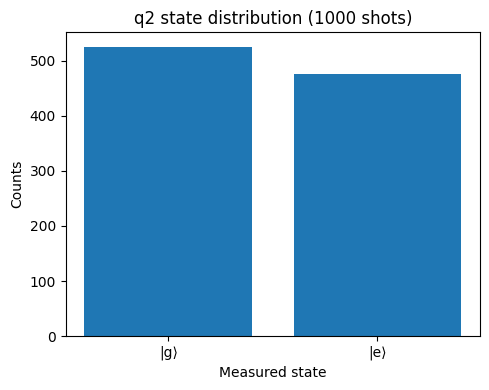

Readout length:          2000 ns
Time of flight:          24 ns
Measure → play (total):  2080 ns
Feed-forward overhead:   80 ns  (min 80, max 80)
FPGA processing:         56 ns  (overhead − ToF)


In [154]:
tof = q_measure.resonator.time_of_flight

n_common = min(len(measure_ts), len(ff_play_ts))
total_latency_ns = (ff_play_ts[:n_common] - measure_ts[:n_common]) * 4
ff_overhead_ns = total_latency_ns - readout_len
fpga_ns = ff_overhead_ns - tof

fig, ax = plt.subplots(figsize=(5, 4))
unique, counts = np.unique(states, return_counts=True)
ax.bar(unique, counts, tick_label=["|g⟩" if u == 0 else "|e⟩" for u in unique])
ax.set_xlabel("Measured state")
ax.set_ylabel("Counts")
ax.set_title(f"q2 state distribution ({n_shots} shots)")
fig.tight_layout()
plt.show()

print(f"Readout length:          {readout_len} ns")
print(f"Time of flight:          {tof} ns")
print(f"Measure → play (total):  {int(np.median(total_latency_ns))} ns")
print(f"Feed-forward overhead:   {int(np.median(ff_overhead_ns))} ns  "
      f"(min {int(np.min(ff_overhead_ns))}, max {int(np.max(ff_overhead_ns))})")
print(f"FPGA processing:         {int(np.median(fpga_ns))} ns  (overhead − ToF)")

## Latency scaling experiments

Starting from a simple baseline, we progressively add real-time complexity
between the `measure` and the conditional `play` to see how the feed-forward
overhead grows.  Each experiment also reports whether the latency is **fixed**
(identical every shot) or **varies** (state-dependent).

1. **Baseline** — measure one qubit, threshold the I quadrature, and
   conditionally play `x180` via `condition=`.  This is the minimal
   feed-forward latency.
2. **Magnitude threshold** — replace the simple `I > threshold` with
   `I² + Q² > threshold²` (two multiplies + an add + compare).
3. **If / else branching** — use an explicit `if_` / `else_` block instead of
   `condition=`, to measure the branch-evaluation overhead.
4. **`update_frequency`** — same `if_`/`else_` structure as experiment 3, but
   the `if_` branch calls `update_frequency` before `play`.  The NCO update
   delay is only enforced by the hardware when `play` directly follows
   `update_frequency` on the same element (no intervening `align`).  The OPX+
   spec quotes frequency update latency at < 268 ns; subtracting the if/else
   baseline gives our measured NCO update cost.
5. **`frame_rotation`** — same `if_`/`else_` structure, but the `if_` branch
   calls `frame_rotation_2pi` before `play`.  The OPX+ spec quotes phase
   update latency at < 32 ns; subtracting the if/else baseline gives our
   measured phase update cost.
6. **Dual-qubit AND** — measure both q2 and q3, AND their states, and
   conditionally play `x180` on both qubits only when both are excited.
7. **3-qubit XOR** — measure q2, q3, and q4, XOR all three thresholded
   states, and conditionally play `x180` on all three qubits when the
   XOR result is true.

In [155]:
def run_ff_experiment(qmm, config, prog, n_shots, readout_len):
    """Execute a feed-forward program and return overhead statistics."""
    with qm_session(qmm, config, timeout=100) as qm:
        job = qm.execute(prog)
        res = fetching_tool(job, ["n"], mode="live")
        while res.is_processing():
            res.fetch_all()
    m_ts = job.result_handles.get("measure_ts").fetch_all()["value"]
    p_ts = job.result_handles.get("ff_play_ts").fetch_all()["value"]
    nc = min(len(m_ts), len(p_ts))
    overhead = (p_ts[:nc] - m_ts[:nc]) * 4 - readout_len
    med = int(np.median(overhead))
    mn = int(np.min(overhead))
    mx = int(np.max(overhead))
    return {"median": med, "min": mn, "max": mx, "constant": mn == mx}


def make_baseline_prog():
    """Baseline: measure, threshold, conditionally play."""
    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(state, I > threshold)
            align()
            q_target.xy.play("x180", condition=state, timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_magnitude_prog():
    """Replace simple threshold with I² + Q² > threshold² (3 extra ops)."""
    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        mag_sq = declare(fixed)
        thresh_sq = declare(fixed)
        n_st = declare_stream()

        assign(thresh_sq, threshold * threshold)

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(mag_sq, I * I)
            assign(mag_sq, mag_sq + Q * Q)
            assign(state, mag_sq > thresh_sq)
            align()
            q_target.xy.play("x180", condition=state, timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_if_else_prog():
    """Use explicit if_/else_ branching instead of condition=."""
    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(state, I > threshold)
            align()
            with if_(state):
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            with else_():
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_update_freq_prog():
    """if/else with update_frequency in the if branch — measures NCO update cost."""
    current_if = int(q_target.xy.intermediate_frequency)

    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(state, I > threshold)
            align()
            with if_(state):
                update_frequency(q_target.xy.name, current_if)
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            with else_():
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_phase_update_prog():
    """if/else with frame_rotation in the if branch — measures phase update cost."""
    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(state, I > threshold)
            align()
            with if_(state):
                frame_rotation_2pi(0.25, q_target.xy.name)
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            with else_():
                q_target.xy.play("x180", timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_dual_qubit_and_prog():
    """Measure both qubits, AND their states, conditionally x180 on both."""
    threshold_2 = q_target.resonator.operations["readout"].threshold

    with program() as prog:
        n = declare(int)
        I1 = declare(fixed)
        Q1 = declare(fixed)
        I2 = declare(fixed)
        Q2 = declare(fixed)
        state1 = declare(bool)
        state2 = declare(bool)
        both_excited = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I1),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q1),
                timestamp_stream="measure_ts",
            )
            measure(
                "readout", q_target.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I2),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q2),
            )
            assign(state1, I1 > threshold)
            assign(state2, I2 > threshold_2)
            assign(both_excited, state1 & state2)
            align()
            q_measure.xy.play("x180", condition=both_excited, timestamp_stream="ff_play_ts")
            q_target.xy.play("x180", condition=both_excited)
            align()
            wait(1000)
        with stream_processing():
            n_st.save("n")
    return prog


def make_triple_qubit_xor_prog():
    """Measure 3 qubits, XOR their states, conditionally x180 on all three."""
    threshold_2 = q_target.resonator.operations["readout"].threshold
    threshold_3 = q_third.resonator.operations["readout"].threshold

    with program() as prog:
        n = declare(int)
        I1 = declare(fixed)
        Q1 = declare(fixed)
        I2 = declare(fixed)
        Q2 = declare(fixed)
        I3 = declare(fixed)
        Q3 = declare(fixed)
        state1 = declare(bool)
        state2 = declare(bool)
        state3 = declare(bool)
        xor12 = declare(bool)
        xor_all = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I1),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q1),
                timestamp_stream="measure_ts",
            )
            measure(
                "readout", q_target.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I2),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q2),
            )
            measure(
                "readout", q_third.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I3),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q3),
            )
            assign(state1, I1 > threshold)
            assign(state2, I2 > threshold_2)
            assign(state3, I3 > threshold_3)
            assign(xor12, state1 ^ state2)
            assign(xor_all, xor12 ^ state3)
            align()
            q_measure.xy.play("x180", condition=xor_all, timestamp_stream="ff_play_ts")
            q_target.xy.play("x180", condition=xor_all)
            q_third.xy.play("x180", condition=xor_all)
            align()
            wait(1000)
        with stream_processing():
            n_st.save("n")
    return prog

In [156]:
experiments = {}

def _tag(result):
    if result["constant"]:
        return "fixed"
    return f"varies: {result['min']}–{result['max']}"

# --- 1) Baseline: measure + conditional play ---
prog = make_baseline_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["baseline"] = result
print(f"  {'baseline':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 2) Magnitude threshold (I² + Q²) ---
prog = make_magnitude_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["I²+Q² threshold"] = result
print(f"  {'I²+Q² thresh':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 3) Explicit if/else branching ---
prog = make_if_else_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["if/else branch"] = result
print(f"  {'if/else':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 4) update_frequency before conditional play ---
prog = make_update_freq_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["update_frequency"] = result
print(f"  {'update_frequency':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 5) frame_rotation before conditional play ---
prog = make_phase_update_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["frame_rotation"] = result
print(f"  {'frame_rotation':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 6) Dual-qubit measurement + AND + conditional play on both ---
prog = make_dual_qubit_and_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["dual-qubit AND"] = result
print(f"  {'dual-qubit AND':>25s} → {result['median']} ns  ({_tag(result)})")

# --- 6) Triple-qubit measurement + XOR + conditional play on all three ---
prog = make_triple_qubit_xor_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
experiments["3-qubit XOR"] = result
print(f"  {'3-qubit XOR':>25s} → {result['median']} ns  ({_tag(result)})")

c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 00:59:31,984 - qm - INFO     - Opening QM
2026-03-26 00:59:32,446 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 00:59:32,928 - qm - INFO     - Executing program
2026-03-26 00:59:34,742 - qm - INFO     - Closing QM
                   baseline → 80 ns  (fixed)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 00:59:36,549 - qm - INFO     - Opening QM
2026-03-26 00:59:36,932 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 00:59:37,549 - qm - INFO     - Executing program
2026-03-26 00:59:39,381 - qm - INFO     - Closing QM
               I²+Q² thresh → 108 ns  (fixed)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


...

2026-03-26 00:59:50,235 - qm - INFO     - Opening QM
2026-03-26 00:59:50,677 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 00:59:51,158 - qm - INFO     - Executing program
2026-03-26 00:59:53,011 - qm - INFO     - Closing QM
             frame_rotation → 128 ns  (varies: 128–144)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 00:59:54,795 - qm - INFO     - Opening QM
2026-03-26 00:59:55,185 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 00:59:55,798 - qm - INFO     - Executing program
2026-03-26 00:59:57,548 - qm - INFO     - Closing QM
             dual-qubit AND → 88 ns  (fixed)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 00:59:59,269 - qm - INFO     - Opening QM
2026-03-26 00:59:59,691 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 01:00:00,284 - qm - INFO     - Executing program
2026-03-26 01:00:01,929 - qm - INFO     - Closing QM
                3-qubit XOR → 92 ns  (fixed)


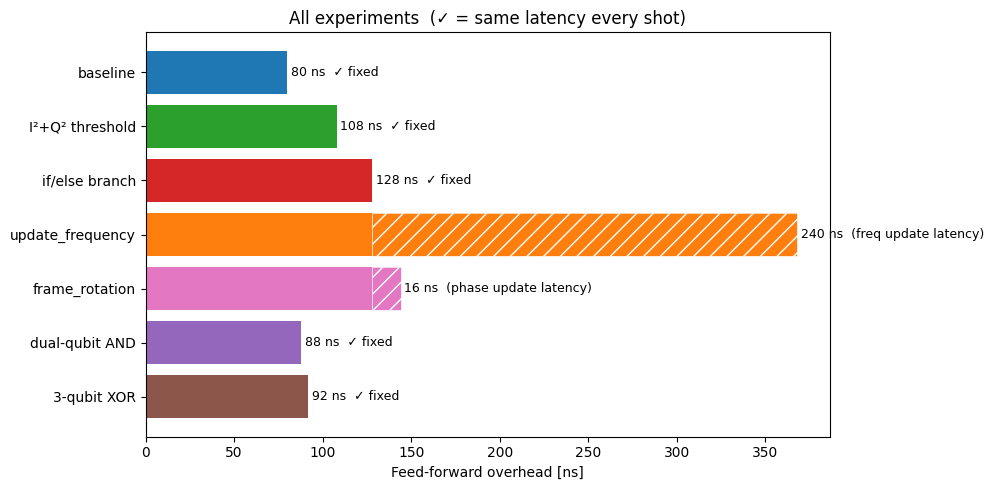

In [157]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(experiments.keys())
colors = ["C0", "C2", "C3", "C1", "C6", "C4", "C5"]

if_else_baseline = experiments.get("if/else branch", {}).get("median", 0)

varying_nco_keys = {"update_frequency", "frame_rotation"}
nco_label = {"update_frequency": "freq update latency", "frame_rotation": "phase update latency"}

bar_values = []
for k in labels:
    r = experiments[k]
    if k in varying_nco_keys:
        bar_values.append(r["max"])
    else:
        bar_values.append(r["median"])

ax.barh(labels, bar_values, color=colors)

for i, (k, v) in enumerate(zip(labels, bar_values)):
    r = experiments[k]
    if k in varying_nco_keys:
        cost = r["max"] - if_else_baseline
        tag = f"{cost} ns  ({nco_label[k]})"
        ax.barh(k, r["min"], color=colors[i], alpha=0.4)
        ax.barh(k, r["max"] - r["min"], left=r["min"], color=colors[i], hatch="//", edgecolor="white", linewidth=0.5)
    elif r["constant"]:
        tag = f"{v} ns  \u2713 fixed"
    else:
        tag = f"{v} ns  ({r['min']}\u2013{r['max']})"
    ax.text(v + 2, i, tag, va="center", fontsize=9)

ax.set_xlabel("Feed-forward overhead [ns]")
ax.set_title("All experiments  (\u2713 = same latency every shot)")
ax.invert_yaxis()

fig.tight_layout()
plt.show()

## Active reset latency experiments

These experiments measure the feed-forward latency of active reset protocols,
where a qubit is measured and conditionally flipped back to the ground state
via an `x180` pulse.

1. **Single-qubit reset** — measure q2 and conditionally play `x180` on q2
   itself to reset it to ground.  This is the minimal active reset.
2. **Independent 3-qubit reset** — measure q2, q3, and q4 simultaneously,
   threshold each independently, and conditionally reset each qubit based
   on its own measurement result.
3. **Collective reset (all excited)** — measure all three qubits, AND all
   three thresholded states, and conditionally reset all three only if
   every qubit was found in the excited state.

In [158]:
def make_single_reset_prog():
    """Single-qubit active reset: measure q2, if excited play x180 on q2."""
    with program() as prog:
        n = declare(int)
        I = declare(fixed)
        Q = declare(fixed)
        state = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q),
                timestamp_stream="measure_ts",
            )
            assign(state, I > threshold)
            align()
            q_measure.xy.play("x180", condition=state, timestamp_stream="ff_play_ts")
            align()
        with stream_processing():
            n_st.save("n")
    return prog


def make_independent_3q_reset_prog():
    """Independent 3-qubit active reset: measure all three, reset each independently."""
    threshold_2 = q_target.resonator.operations["readout"].threshold
    threshold_3 = q_third.resonator.operations["readout"].threshold

    with program() as prog:
        n = declare(int)
        I1 = declare(fixed)
        Q1 = declare(fixed)
        I2 = declare(fixed)
        Q2 = declare(fixed)
        I3 = declare(fixed)
        Q3 = declare(fixed)
        state1 = declare(bool)
        state2 = declare(bool)
        state3 = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I1),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q1),
                timestamp_stream="measure_ts",
            )
            measure(
                "readout", q_target.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I2),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q2),
            )
            measure(
                "readout", q_third.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I3),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q3),
            )
            assign(state1, I1 > threshold)
            assign(state2, I2 > threshold_2)
            assign(state3, I3 > threshold_3)
            align()
            q_measure.xy.play("x180", condition=state1, timestamp_stream="ff_play_ts")
            q_target.xy.play("x180", condition=state2)
            q_third.xy.play("x180", condition=state3)
            align()
            wait(1000)
        with stream_processing():
            n_st.save("n")
    return prog


def make_collective_reset_prog():
    """Collective active reset: reset all three only if every qubit is excited."""
    threshold_2 = q_target.resonator.operations["readout"].threshold
    threshold_3 = q_third.resonator.operations["readout"].threshold

    with program() as prog:
        n = declare(int)
        I1 = declare(fixed)
        Q1 = declare(fixed)
        I2 = declare(fixed)
        Q2 = declare(fixed)
        I3 = declare(fixed)
        Q3 = declare(fixed)
        state1 = declare(bool)
        state2 = declare(bool)
        state3 = declare(bool)
        all_excited = declare(bool)
        n_st = declare_stream()

        with for_(n, 0, n < n_shots, n + 1):
            save(n, n_st)
            measure(
                "readout", q_measure.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I1),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q1),
                timestamp_stream="measure_ts",
            )
            measure(
                "readout", q_target.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I2),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q2),
            )
            measure(
                "readout", q_third.resonator.name,
                dual_demod.full("iw1", "out1", "iw2", "out2", I3),
                dual_demod.full("iw3", "out1", "iw1", "out2", Q3),
            )
            assign(state1, I1 > threshold)
            assign(state2, I2 > threshold_2)
            assign(state3, I3 > threshold_3)
            assign(all_excited, state1 & state2 & state3)
            align()
            q_measure.xy.play("x180", condition=all_excited, timestamp_stream="ff_play_ts")
            q_target.xy.play("x180", condition=all_excited)
            q_third.xy.play("x180", condition=all_excited)
            align()
            wait(1000)
        with stream_processing():
            n_st.save("n")
    return prog

In [159]:
reset_experiments = {}

# --- 1) Single-qubit active reset ---
prog = make_single_reset_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
reset_experiments["1Q reset"] = result
print(f"  {'1Q reset':>30s} → {result['median']} ns  ({_tag(result)})")

# --- 2) Independent 3-qubit active reset ---
prog = make_independent_3q_reset_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
reset_experiments["3Q independent reset"] = result
print(f"  {'3Q independent reset':>30s} → {result['median']} ns  ({_tag(result)})")

# --- 3) Collective active reset (all excited) ---
prog = make_collective_reset_prog()
result = run_ff_experiment(qmm, config, prog, n_shots, readout_len)
reset_experiments["3Q collective reset"] = result
print(f"  {'3Q collective reset':>30s} → {result['median']} ns  ({_tag(result)})")

c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 01:00:04,210 - qm - INFO     - Opening QM
2026-03-26 01:00:04,602 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 01:00:05,081 - qm - INFO     - Executing program
2026-03-26 01:00:06,929 - qm - INFO     - Closing QM
                        1Q reset → 80 ns  (fixed)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 01:00:08,739 - qm - INFO     - Opening QM
2026-03-26 01:00:09,186 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 01:00:09,829 - qm - INFO     - Executing program
2026-03-26 01:00:11,603 - qm - INFO     - Closing QM
            3Q independent reset → 80 ns  (fixed)


c:\Users\BenjaminSafvati\.local\share\mamba\envs\QM1\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


2026-03-26 01:00:13,422 - qm - INFO     - Opening QM
2026-03-26 01:00:13,816 - qm - INFO     - Sending program to QOP for compilation
2026-03-26 01:00:14,546 - qm - INFO     - Executing program
2026-03-26 01:00:16,280 - qm - INFO     - Closing QM
             3Q collective reset → 92 ns  (fixed)


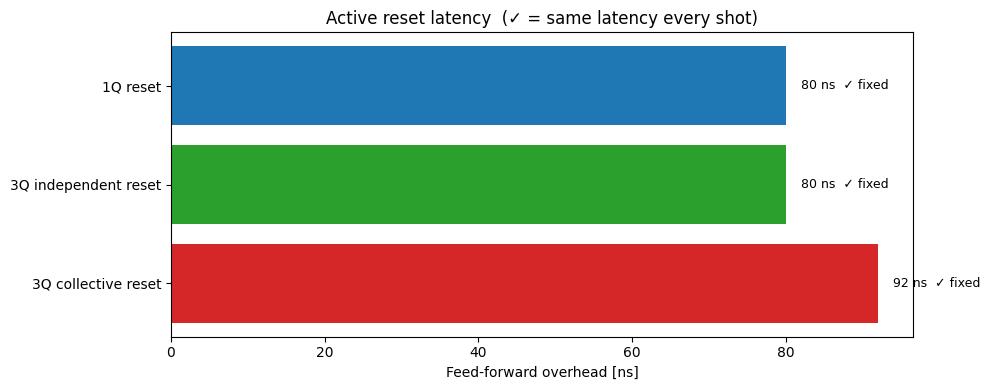

In [160]:
fig, ax = plt.subplots(figsize=(10, 4))

labels = list(reset_experiments.keys())
colors = ["C0", "C2", "C3"]

bar_values = [reset_experiments[k]["median"] for k in labels]

ax.barh(labels, bar_values, color=colors)

for i, (k, v) in enumerate(zip(labels, bar_values)):
    r = reset_experiments[k]
    if r["constant"]:
        tag = f"{v} ns  \u2713 fixed"
    else:
        tag = f"{v} ns  ({r['min']}\u2013{r['max']})"
    ax.text(v + 2, i, tag, va="center", fontsize=9)

ax.set_xlabel("Feed-forward overhead [ns]")
ax.set_title("Active reset latency  (\u2713 = same latency every shot)")
ax.invert_yaxis()

fig.tight_layout()
plt.show()